# Working Model: Three-Layer Energy Balance Model with Variable Atmospheric Emissivity
### Atmosphere · Upper Ocean (0–200 m) · Lower Ocean (>200 m)

This notebook combines the two source models in this repo:

- **`TwoLayerModel_VarEm.ipynb`** — CO₂ forcing represented physically through a
  CO₂-dependent atmospheric emissivity $\varepsilon(\mathrm{CO_2})$ (Myhre et al. 1998
  logarithmic forcing folded into a grey-body OLR, $OLR = \varepsilon\sigma T_a^4$),
  driven by **real CO₂ data** (historical + SSP pathways), plus stratospheric aerosol
  injection (SAI) with a ramp/slope profile and two closed-loop SAI controllers.
- **`multliayerModel.ipynb`** — a third prognostic layer: the ocean is split into a
  fast **upper layer** (0–200 m) and a slow **lower/deep layer** (>200 m), coupled by a
  deep-ocean heat-uptake efficiency $\gamma_{ul}$, so the model carries the atmosphere's
  fast response and the ocean's two distinct (decadal vs. centennial) response
  timescales instead of one lumped ocean layer.

$$C_a\frac{dT_a}{dt} = S\bigl(1-\alpha_{net}(T_a,t)\bigr) - \varepsilon\bigl(\mathrm{CO_2}(t)\bigr)\sigma T_a^4 - \gamma_{au}(T_a - T_u)$$
$$C_u\frac{dT_u}{dt} = \gamma_{au}(T_a - T_u) - \gamma_{ul}(T_u - T_l)$$
$$C_l\frac{dT_l}{dt} = \gamma_{ul}(T_u - T_l)$$
$$\varepsilon(\mathrm{CO_2}) = \varepsilon_0 - \frac{5.35\,\ln(\mathrm{CO_2}/\mathrm{CO_2}_0)}{\sigma T_0^4}$$
$$\alpha_{net}(T_a,t) = 1 - \frac{\bigl(1-\alpha_{earth}(T_a)\bigr)\bigl(1-\alpha_{SAI}(t)\bigr)}{1-\alpha_{earth}(T_a)\,\alpha_{SAI}(t)},
\qquad \alpha_{earth}(T) = 1.82 - 0.00526\,T$$

| Symbol | Meaning | Units |
|--------|---------|-------|
| $T_a,\,T_u,\,T_l$ | Atmosphere / upper-ocean / lower-ocean temperature | K |
| $C_a$ | Atmospheric-column heat capacity | W·yr/m²/°C |
| $C_u$ | Upper-ocean (0–200 m) heat capacity | W·yr/m²/°C |
| $C_l$ | Lower-ocean (>200 m) heat capacity | W·yr/m²/°C |
| $\gamma_{au}$ | Atmosphere ↔ upper-ocean heat exchange | W/m²/°C |
| $\gamma_{ul}$ | Upper ↔ lower-ocean heat exchange (deep uptake) | W/m²/°C |
| $\sigma$ | Stefan–Boltzmann constant | W/m²/K⁴ |
| $\varepsilon(\mathrm{CO_2})$ | Effective atmospheric emissivity | dimensionless |
| $\mathrm{CO_2}(t)$ | Atmospheric CO₂ concentration (real historical + SSP data) | ppm |
| $S$ | Sphere-averaged mean insolation | W/m² |
| $\alpha_{earth}(T)$ | Temperature-dependent earth albedo, $1.82-0.00526\,T$ | dimensionless |
| $\alpha_{SAI}(t)$ | SAI aerosol-layer albedo (pure scattering, no absorption) | dimensionless |
| $\alpha_{net}$ | System albedo after multiple surface–aerosol reflections | dimensionless |

Only the atmosphere exchanges radiation with space, so both the CO₂-driven emissivity
change and the SAI albedo offset act on $T_a$; heat then flows downward through the
ocean via $\gamma_{au}$ and $\gamma_{ul}$. The model horizon is **1850–2100**, matching
the available CO₂ record. Set `RUN_START_YEAR = 2015` in the *Simulation window* cell to
run only 2015–2100; the 2015 starting state then comes from a no-SAI 1850–2015 spin-up.


In [11]:
%matplotlib inline
import functools
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})


## Temperature-Dependent Albedo and the SAI Multiple-Reflection Series

Two changes to the shortwave side of the model, both live in the constants cell below.

**1. The earth's albedo now responds to temperature.** A linear Budyko-style
ice-albedo parameterization replaces the fixed $\alpha_0 = 0.30$:

$$\alpha_{earth}(T) = 1.82 - 0.00526\,T \qquad (T \text{ in kelvin})$$

clipped to $[0.15,\,0.65]$. At the pre-industrial baseline $T_0 = 288.15$ K this gives
$\alpha_{earth} = 0.3043$, and $\varepsilon_0$ is re-derived from *that* value so the
control run still equilibrates at exactly $T_0$.

This is a **positive feedback** worth about $S\,B = 1.79$ W/m²/K, against a Planck term
of $\approx 3.31$ W/m²/K — so the net feedback drops to $\approx 1.52$ W/m²/K and the
climate sensitivity of the model roughly doubles relative to the fixed-albedo version.
The system is still stable (net feedback $> 0$), but every run below will warm more, and
the controllers will call for more SAI.

**2. SAI and the earth's albedo combine through an infinite reflection series,
not by addition.** The SAI aerosols are treated as pure scatterers (no absorption), so
transmission through the layer is $1-\alpha_{SAI}$. Light absorbed by the surface must
cross the layer at least once; beyond that it can bounce between the surface and the
underside of the aerosol layer any number of times, each round trip carrying probability
$\alpha_{earth}\alpha_{SAI}$:

$$P_{abs} = (1-\alpha_{earth})(1-\alpha_{SAI})\sum_{n=0}^{\infty}(\alpha_{earth}\alpha_{SAI})^n
= \frac{(1-\alpha_{earth})(1-\alpha_{SAI})}{1-\alpha_{earth}\alpha_{SAI}}$$

$$\alpha_{net}(T,t) = 1 - P_{abs} = 1 - \frac{\bigl(1-\alpha_{earth}(T)\bigr)\bigl(1-\alpha_{SAI}(t)\bigr)}{1-\alpha_{earth}(T)\,\alpha_{SAI}(t)}$$

Those recovered bounces mean SAI is **less effective than its face value**: at $T_0$,
$\alpha_{SAI} = 0.015$ raises the system albedo by only $0.0073$, not $0.015$. The
`d_alpha` knob and both SAI controllers now carry the meaning $\alpha_{SAI}$ — the
aerosol layer's own reflectance — rather than a planetary-albedo offset, so open-loop
runs at a given `d_alpha` cool roughly half as much as they used to. The controllers
absorb this automatically: each solves for the *absorbed flux* it needs and then inverts
$\alpha_{net}$ in closed form,

$$\alpha_{SAI} = \frac{(1-\alpha_{earth}) - A}{(1-\alpha_{earth}) - A\,\alpha_{earth}},
\qquad A = R_{target}/S,$$

clipped at zero since injection can only add reflectance.


In [12]:
# == Physical constants =======================================================
S0     = 1361.0   # Solar constant [W/m2]
S      = S0 / 4   # Sphere-averaged mean insolation [W/m2]
SIGMA  = 5.670374419e-8   # Stefan-Boltzmann constant [W/m2/K4]

# == Pre-industrial baseline (1850) ===========================================
T0     = 288.15   # Surface temperature [K]  (~15 C)

# == Temperature-dependent earth albedo =======================================
# Budyko-style linear ice-albedo parameterization,  alpha_earth(T) = A - B*T,
# with T the ATMOSPHERIC temperature in KELVIN: colder -> more snow/ice cover ->
# higher albedo.  Clipped to a physically meaningful range (ice-free floor,
# snowball ceiling); over 1850-2100 the clip should never engage.
ALBEDO_A   = 1.82      # intercept [-]
ALBEDO_B   = 0.00526   # slope [1/K]  ->  d(alpha_earth)/dT = -0.00526 /K
ALBEDO_MIN = 0.15      # ice-free lower bound
ALBEDO_MAX = 0.65      # snowball upper bound


def alpha_earth(T):
    """Temperature-dependent earth albedo [-] (surface + non-SAI atmosphere)."""
    return np.clip(ALBEDO_A - ALBEDO_B * np.asarray(T, dtype=float),
                   ALBEDO_MIN, ALBEDO_MAX)[()]


def alpha_net(T, alpha_sai=0.0):
    """
    Total system albedo with a purely scattering SAI layer above the surface.

    Any energy the earth absorbs must be transmitted through the aerosol layer
    at least once (transmission 1 - alpha_SAI, no aerosol absorption assumed).
    It can then be reflected by the surface and scattered back down by the layer
    any number of times, each round trip carrying probability
    alpha_earth*alpha_SAI.  Summing that infinite geometric series,

        P_abs = (1-alpha_earth)(1-alpha_SAI) * sum_n (alpha_earth*alpha_SAI)^n
              = (1-alpha_earth)(1-alpha_SAI) / (1 - alpha_earth*alpha_SAI),

    and the system albedo is the reflected complement, alpha_net = 1 - P_abs.

    NOTE this is NOT alpha_earth + alpha_SAI.  The multiple reflections recover
    part of the light the aerosol layer scatters back upward, so a given
    alpha_SAI buys noticeably less than its face value in planetary
    reflectance (e.g. alpha_SAI = 0.015 at T0 raises alpha_net by only ~0.007).
    """
    a_e = alpha_earth(T)
    a_s = np.clip(np.asarray(alpha_sai, dtype=float), 0.0, 0.999)[()]
    return 1.0 - (1.0 - a_e) * (1.0 - a_s) / (1.0 - a_e * a_s)


def absorbed_sw(T, alpha_sai=0.0):
    """Absorbed shortwave flux  S*(1 - alpha_net)  [W/m2]."""
    return S * (1.0 - alpha_net(T, alpha_sai))


def alpha_sai_for_absorbed_sw(T, R_target):
    """
    Invert alpha_net(): the SAI-layer albedo that makes the absorbed shortwave
    equal R_target [W/m2] at temperature T.  Solving

        A = (1-a_e)(1-x) / (1 - a_e*x)   for x,   A = R_target/S

    gives the closed form

        x = [(1-a_e) - A] / [(1-a_e) - A*a_e].

    Clipped to [0, 0.999): SAI can only ADD reflective aerosol, so a negative
    solution (the target already absorbs less than the bare earth would) means
    no injection.
    """
    a_e   = float(alpha_earth(T))
    A     = R_target / S
    denom = (1.0 - a_e) - A * a_e
    if denom <= 0.0:
        return 0.0
    return float(np.clip(((1.0 - a_e) - A) / denom, 0.0, 0.999))


alpha0 = float(alpha_earth(T0))   # pre-industrial planetary albedo = alpha_earth(T0), no SAI

# == CO2 -> emissivity: Myhre et al. (1998) logarithmic forcing =============
CO2_0 = 280.0     # pre-industrial CO2 concentration [ppm]
K_CO2 = 5.35      # log-CO2 forcing coefficient [W/m2]

# OLR = eps(CO2) * SIGMA * Ta^4 ; eps0 is set so that CO2=CO2_0 gives T_eq = T0 exactly.
OLR0 = S * (1 - alpha0)          # required pre-industrial OLR [W/m2]  (alpha0 = alpha_earth(T0))
EPS0 = OLR0 / (SIGMA * T0**4)    # pre-industrial effective atmospheric emissivity [-]

# == Layer heat capacities ====================================================
# Ocean layer:  C = rho * c_p * h * f_ocean / (seconds per year)   [W.yr/m2/K]
# Atmosphere :  C = c_p_air * p_s / g       / (seconds per year)
RHO_W      = 1025.0     # seawater density [kg/m3]
CP_W       = 3990.0     # seawater heat capacity [J/kg/K]
F_OCEAN    = 0.71       # ocean fraction of Earth's surface
CP_AIR     = 1004.0     # air heat capacity [J/kg/K]
P_SURF     = 1.01325e5  # surface pressure [Pa]
G_GRAV     = 9.81       # gravity [m/s2]
SEC_PER_YR = 3.1557e7

UPPER_DEPTH = 200.0     # upper-ocean thickness [m]
LOWER_DEPTH = 3500.0    # lower-ocean thickness [m]  (ocean below 200 m; mean depth ~3700 m)

def ocean_layer_C(depth_m, f_ocean=F_OCEAN):
    '''Heat capacity per m2 of Earth for an ocean layer [W.yr/m2/K].'''
    return RHO_W * CP_W * depth_m * f_ocean / SEC_PER_YR

C_ATMOS = CP_AIR * P_SURF / G_GRAV / SEC_PER_YR     # atmospheric column
C_UPPER = ocean_layer_C(UPPER_DEPTH)                # fast (upper) ocean layer
C_LOWER = ocean_layer_C(LOWER_DEPTH)                # slow (deep) ocean layer

# == Inter-layer heat-exchange coefficients [W/m2/K] ==========================
GAMMA_AU = 5.0   # atmosphere <-> upper ocean (10 = strong air-sea coupling)
GAMMA_UL = 0.7    # upper <-> lower ocean (deep-ocean heat-uptake efficiency; Geoffroy 2013)

B_PLANCK = 4 * EPS0 * SIGMA * T0**3   # Planck feedback at T0, for comparison to the
                                       # tuned b=2.09 W/m2/K slope in the linear-OLR models

print(f"Pre-industrial OLR = {OLR0:.3f} W/m2  ->  eps0 = {EPS0:.4f}")
print(f"Planck feedback at T0:  4*eps0*sigma*T0^3 = {B_PLANCK:.3f} W/m2/K  "
      f"(cf. tuned b = 2.09 W/m2/K in the linear-OLR models)")
print(f"Heat capacities [W.yr/m2/K]:  C_a = {C_ATMOS:.3f}   C_u = {C_UPPER:.2f}   C_l = {C_LOWER:.1f}")
print(f"Response timescales:  atmosphere ~ {C_ATMOS/(B_PLANCK+GAMMA_AU):.3f} yr   "
      f"upper ocean ~ {C_UPPER/GAMMA_UL:.0f} yr   deep ocean ~ {C_LOWER/GAMMA_UL:.0f} yr")
print(f"Equilibrium check  ->  T_eq = {(OLR0/(EPS0*SIGMA))**0.25:.4f} K  (target: {T0} K)")
print(f"Albedo:  alpha_earth(T0) = {alpha0:.4f}   (slope {-ALBEDO_B:+.5f} /K, clipped to "
      f"[{ALBEDO_MIN}, {ALBEDO_MAX}])")
print(f"  shortwave (ice-albedo) feedback  S*B = {S*ALBEDO_B:.3f} W/m2/K  ->  net feedback "
      f"{B_PLANCK - S*ALBEDO_B:.3f} W/m2/K  (vs. {B_PLANCK:.3f} with a fixed albedo)")
print(f"  SAI example: alpha_SAI = 0.015 at T0  ->  alpha_net = {alpha_net(T0, 0.015):.4f} "
      f"(a rise of {alpha_net(T0, 0.015) - alpha0:.4f}, not 0.0150)")


Pre-industrial OLR = 236.701 W/m2  ->  eps0 = 0.6055
Planck feedback at T0:  4*eps0*sigma*T0^3 = 3.286 W/m2/K  (cf. tuned b = 2.09 W/m2/K in the linear-OLR models)
Heat capacities [W.yr/m2/K]:  C_a = 0.329   C_u = 18.40   C_l = 322.1
Response timescales:  atmosphere ~ 0.040 yr   upper ocean ~ 26 yr   deep ocean ~ 460 yr
Equilibrium check  ->  T_eq = 288.1500 K  (target: 288.15 K)
Albedo:  alpha_earth(T0) = 0.3043   (slope -0.00526 /K, clipped to [0.15, 0.65])
  shortwave (ice-albedo) feedback  S*B = 1.790 W/m2/K  ->  net feedback 1.496 W/m2/K  (vs. 3.286 with a fixed albedo)
  SAI example: alpha_SAI = 0.015 at T0  ->  alpha_net = 0.3116 (a rise of 0.0073, not 0.0150)


In [13]:
# Real CO2 data, replacing any synthetic linear-ramp / RCP-forcing approximation:
#
#   1850-1978 : Meinshausen et al. (2017) / CMIP6 historical GHG
#               concentrations (RCMIP "historical" series).
#   1979-2023 : NOAA GML observed global annual-mean CO2 -- real
#               measurements, not a reconstruction.
#   2024-2100 : RCMIP/CMIP6 SSP concentration pathway for the chosen
#               scenario (SSP1-2.6 / SSP2-4.5 / SSP5-8.5), offset-anchored
#               to the actual 2023 observed value so each projection
#               continues smoothly from real data instead of jumping to
#               RCMIP's (decade-old, slightly higher) projected 2023 value.
#
# See data/co2_historical_1850_2023.csv and data/co2_ssp_scenarios_2024_2100.csv
# (built from https://zenodo.org/records/4589756 and
# https://gml.noaa.gov/ccgg/trends/gl_data.html).
DATA_DIR = None
for _candidate in [pathlib.Path("data"), pathlib.Path("../data")]:
    if (_candidate / "co2_historical_1850_2023.csv").exists():
        DATA_DIR = _candidate
        break
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find data/co2_historical_1850_2023.csv -- run this notebook "
        "from the 'code' directory it lives in (or alongside a sibling 'data' folder)."
    )

SSP_SCENARIOS = ['ssp126', 'ssp245', 'ssp585']


def _load_co2_data():
    hist = np.genfromtxt(DATA_DIR / "co2_historical_1850_2023.csv", delimiter=",", skip_header=1)
    ssp  = np.genfromtxt(DATA_DIR / "co2_ssp_scenarios_2024_2100.csv", delimiter=",", skip_header=1)
    hist_years, hist_ppm = hist[:, 0], hist[:, 1]
    ssp_years = ssp[:, 0]
    ssp_cols  = {'ssp126': ssp[:, 1], 'ssp245': ssp[:, 2], 'ssp585': ssp[:, 3]}

    years_by_scenario, ppm_by_scenario = {}, {}
    for name in SSP_SCENARIOS:
        years_by_scenario[name] = np.concatenate([hist_years, ssp_years])
        ppm_by_scenario[name]   = np.concatenate([hist_ppm, ssp_cols[name]])
    return years_by_scenario, ppm_by_scenario


_CO2_YEARS, _CO2_PPM = _load_co2_data()


def co2_ppm(t, scenario='ssp245'):
    '''
    Atmospheric CO2 concentration [ppm] -- real historical record spliced
    with a real SSP concentration pathway (see module docstring above).
    'none' is a pre-industrial control: CO2 held at CO2_0 for all t.
    '''
    if scenario == 'none':
        return CO2_0
    return np.interp(t, _CO2_YEARS[scenario], _CO2_PPM[scenario])


def co2_forcing(t, scenario='ssp245'):
    '''
    CO2 radiative forcing relative to pre-industrial [W/m2], via the
    Myhre et al. (1998) logarithmic formula applied to the real CO2 record
    from co2_ppm() (rather than an independently-fit forcing curve).
    '''
    if scenario == 'none':
        return 0.0
    return K_CO2 * np.log(co2_ppm(t, scenario=scenario) / CO2_0)


def emissivity(CO2):
    '''
    Effective atmospheric emissivity: decreases (atmosphere becomes more
    IR-opaque) as CO2 rises above CO2_0. Vectorized over CO2.
    '''
    return EPS0 - K_CO2 * np.log(CO2 / CO2_0) / (SIGMA * T0**4)


In [14]:
# == Simulation window ========================================================
# RUN_START_YEAR = 1850 : full run 1850-2100, starting from pre-industrial
#                         equilibrium [T0, T0, T0].
# RUN_START_YEAR = 2015 : run (and plot) only 2015-2100.  The 2015 state is taken
#                         from a no-SAI spin-up over 1850-2015 with the same layer
#                         parameters, so the ocean layers start with their
#                         historical warming instead of cold at T0 under 2015 CO2.
#                         Any SAI must start at or after RUN_START_YEAR.
SPINUP_START_YEAR = 1850   # pre-industrial equilibrium year (start of the CO2 record)
RUN_START_YEAR    = 2015   # 1850 or 2015
RUN_END_YEAR      = 2100


In [15]:
def sai_delta_alpha(t, d_alpha=0.0, start_year=2030, ramp_years=10, d_alpha_slope=0.0):
    '''
    Albedo of the stratospheric-aerosol-injection (SAI) scattering layer,
    alpha_SAI(t).

    NOTE: this is the aerosol layer's OWN reflectance, not an additive offset to
    the planetary albedo.  It is combined with the temperature-dependent earth
    albedo through alpha_net() (the multiple-reflection geometric series), so
    the planetary albedo rises by less than alpha_SAI.  The knob keeps the name
    d_alpha throughout for continuity with the earlier fixed-albedo version.

    Phase 1 - pre-deployment  [t < start_year]:              0
    Phase 2 - ramp-up         [start_year, start_year+ramp): linear 0 -> d_alpha
    Phase 3 - post-ramp       [t >= start_year+ramp):        d_alpha + d_alpha_slope*(t-ramp_end)
    '''
    if d_alpha == 0.0 or t < start_year:
        return 0.0
    ramp_end = start_year + ramp_years
    if t < ramp_end:
        return d_alpha * (t - start_year) / ramp_years
    return d_alpha + d_alpha_slope * (t - ramp_end)


def net_toa_imbalance(t, Ta, d_alpha=0.0, scenario='ssp245',
                      sai_start=2030, sai_ramp=10, d_alpha_slope=0.0):
    '''
    Net top-of-atmosphere radiative flux [W/m2]

        Q = S*(1 - alpha_net(Ta, alpha_SAI(t))) - eps(CO2(t))*sigma*Ta^4

    where alpha_net combines the temperature-dependent earth albedo with the
    SAI layer through the multiple-reflection series (see alpha_net above).
    The shortwave term is now state-dependent through alpha_earth(Ta), so it
    carries an ice-albedo feedback as well as the SAI forcing.
    '''
    a_sai = sai_delta_alpha(t, d_alpha=d_alpha, start_year=sai_start,
                            ramp_years=sai_ramp, d_alpha_slope=d_alpha_slope)
    alpha = alpha_net(Ta, a_sai)
    eps = emissivity(co2_ppm(t, scenario=scenario))
    return S * (1 - alpha) - eps * SIGMA * Ta**4


def layer_derivs(t, y, C_a, C_u, C_l, gamma_au, gamma_ul,
                 d_alpha=0.0, scenario='ssp245', sai_start=2030, sai_ramp=10, d_alpha_slope=0.0):
    '''
    Right-hand side of the three-layer system.  y = [T_a, T_u, T_l].

    Only the atmosphere sees the net TOA radiation -- whose OLR term depends on the
    CO2-dependent emissivity eps(CO2(t)) rather than a linear a+bT+F(t) -- and it
    exchanges heat with the upper ocean; the upper ocean in turn exchanges heat with
    the deep ocean at the (much slower) rate gamma_ul.
    '''
    Ta, Tu, Tl = y
    R    = net_toa_imbalance(t, Ta, d_alpha, scenario, sai_start, sai_ramp, d_alpha_slope)
    f_au = gamma_au * (Ta - Tu)   # atmosphere -> upper ocean
    f_ul = gamma_ul * (Tu - Tl)   # upper ocean -> lower ocean
    return [(R - f_au) / C_a,
            (f_au - f_ul) / C_u,
            (f_ul)        / C_l]


def _resolve_t_span(t_span):
    '''None -> the notebook-wide simulation window (RUN_START_YEAR, RUN_END_YEAR).'''
    return (RUN_START_YEAR, RUN_END_YEAR) if t_span is None else tuple(t_span)


@functools.lru_cache(maxsize=256)
def initial_state(t_start, C_a=C_ATMOS, C_u=C_UPPER, C_l=C_LOWER,
                  gamma_au=GAMMA_AU, gamma_ul=GAMMA_UL, scenario='ssp245'):
    '''
    Model state (T_a, T_u, T_l) at t_start.

    t_start <= SPINUP_START_YEAR : pre-industrial equilibrium (T0, T0, T0).
    later t_start                : end state of a no-SAI spin-up run from
                                   SPINUP_START_YEAR to t_start with the same
                                   layer parameters and CO2 record.  Cached, since
                                   the interactive plots call this repeatedly.
    '''
    if t_start <= SPINUP_START_YEAR:
        return (T0, T0, T0)
    sol = solve_ivp(lambda t, y: layer_derivs(t, y, C_a, C_u, C_l, gamma_au, gamma_ul,
                                              d_alpha=0.0, scenario=scenario),
                    (SPINUP_START_YEAR, t_start), [T0, T0, T0],
                    method='BDF', rtol=1e-8, atol=1e-10)
    return tuple(float(v) for v in sol.y[:, -1])


def run_ebm(C_a=C_ATMOS, C_u=C_UPPER, C_l=C_LOWER,
            gamma_au=GAMMA_AU, gamma_ul=GAMMA_UL,
            scenario='ssp245', d_alpha=0.0, sai_start=2030, sai_ramp=10,
            d_alpha_slope=0.0, t_span=None, n_pts=2400):
    '''
    Integrate the three-layer EBM over t_span (default: RUN_START_YEAR to
    RUN_END_YEAR), starting from initial_state(t_span[0]).

    The T_a^4 emissivity-based OLR term is nonlinear on top of the usual
    stiff atmosphere/upper-ocean/deep-ocean timescale split -> still solved
    with the implicit BDF method.

    Returns
    -------
    t  : time [years]
    Ta : atmospheric temperature  [K]
    Tu : upper-ocean temperature  [K]
    Tl : lower-ocean temperature  [K]
    Q  : net TOA energy imbalance [W/m2]
    '''
    kw   = dict(d_alpha=d_alpha, scenario=scenario, sai_start=sai_start,
                sai_ramp=sai_ramp, d_alpha_slope=d_alpha_slope)
    args = (C_a, C_u, C_l, gamma_au, gamma_ul)

    t_span = _resolve_t_span(t_span)
    y0     = list(initial_state(t_span[0], *args, scenario=scenario))
    t_eval = np.linspace(*t_span, n_pts)
    sol = solve_ivp(lambda t, y: layer_derivs(t, y, *args, **kw),
                    t_span, y0, t_eval=t_eval,
                    method='BDF', rtol=1e-8, atol=1e-10)

    Ta, Tu, Tl = sol.y
    Q = np.array([net_toa_imbalance(ti, Ta_i, **kw) for ti, Ta_i in zip(sol.t, Ta)])
    return sol.t, Ta, Tu, Tl, Q


## Scenario Comparison

**Left column** - CO2 forcing only (no SAI), across a pre-industrial control and three
SSP pathways (SSP1-2.6, SSP2-4.5, SSP5-8.5).
**Right column** - SAI at varying deployment levels under SSP2-4.5.

Rows (top -> bottom): **atmospheric temperature** $T_a$, **upper-ocean** temperature
change $\Delta T_u$, **lower-ocean** temperature change $\Delta T_l$, and the **energy
imbalance** $Q$ (net TOA flux, $S(1-\alpha) - \varepsilon(\mathrm{CO_2})\sigma T_a^4$).
Note how the deep ocean lags and warms only a fraction of the surface amount over this
period - the signature of slow deep-ocean heat uptake.


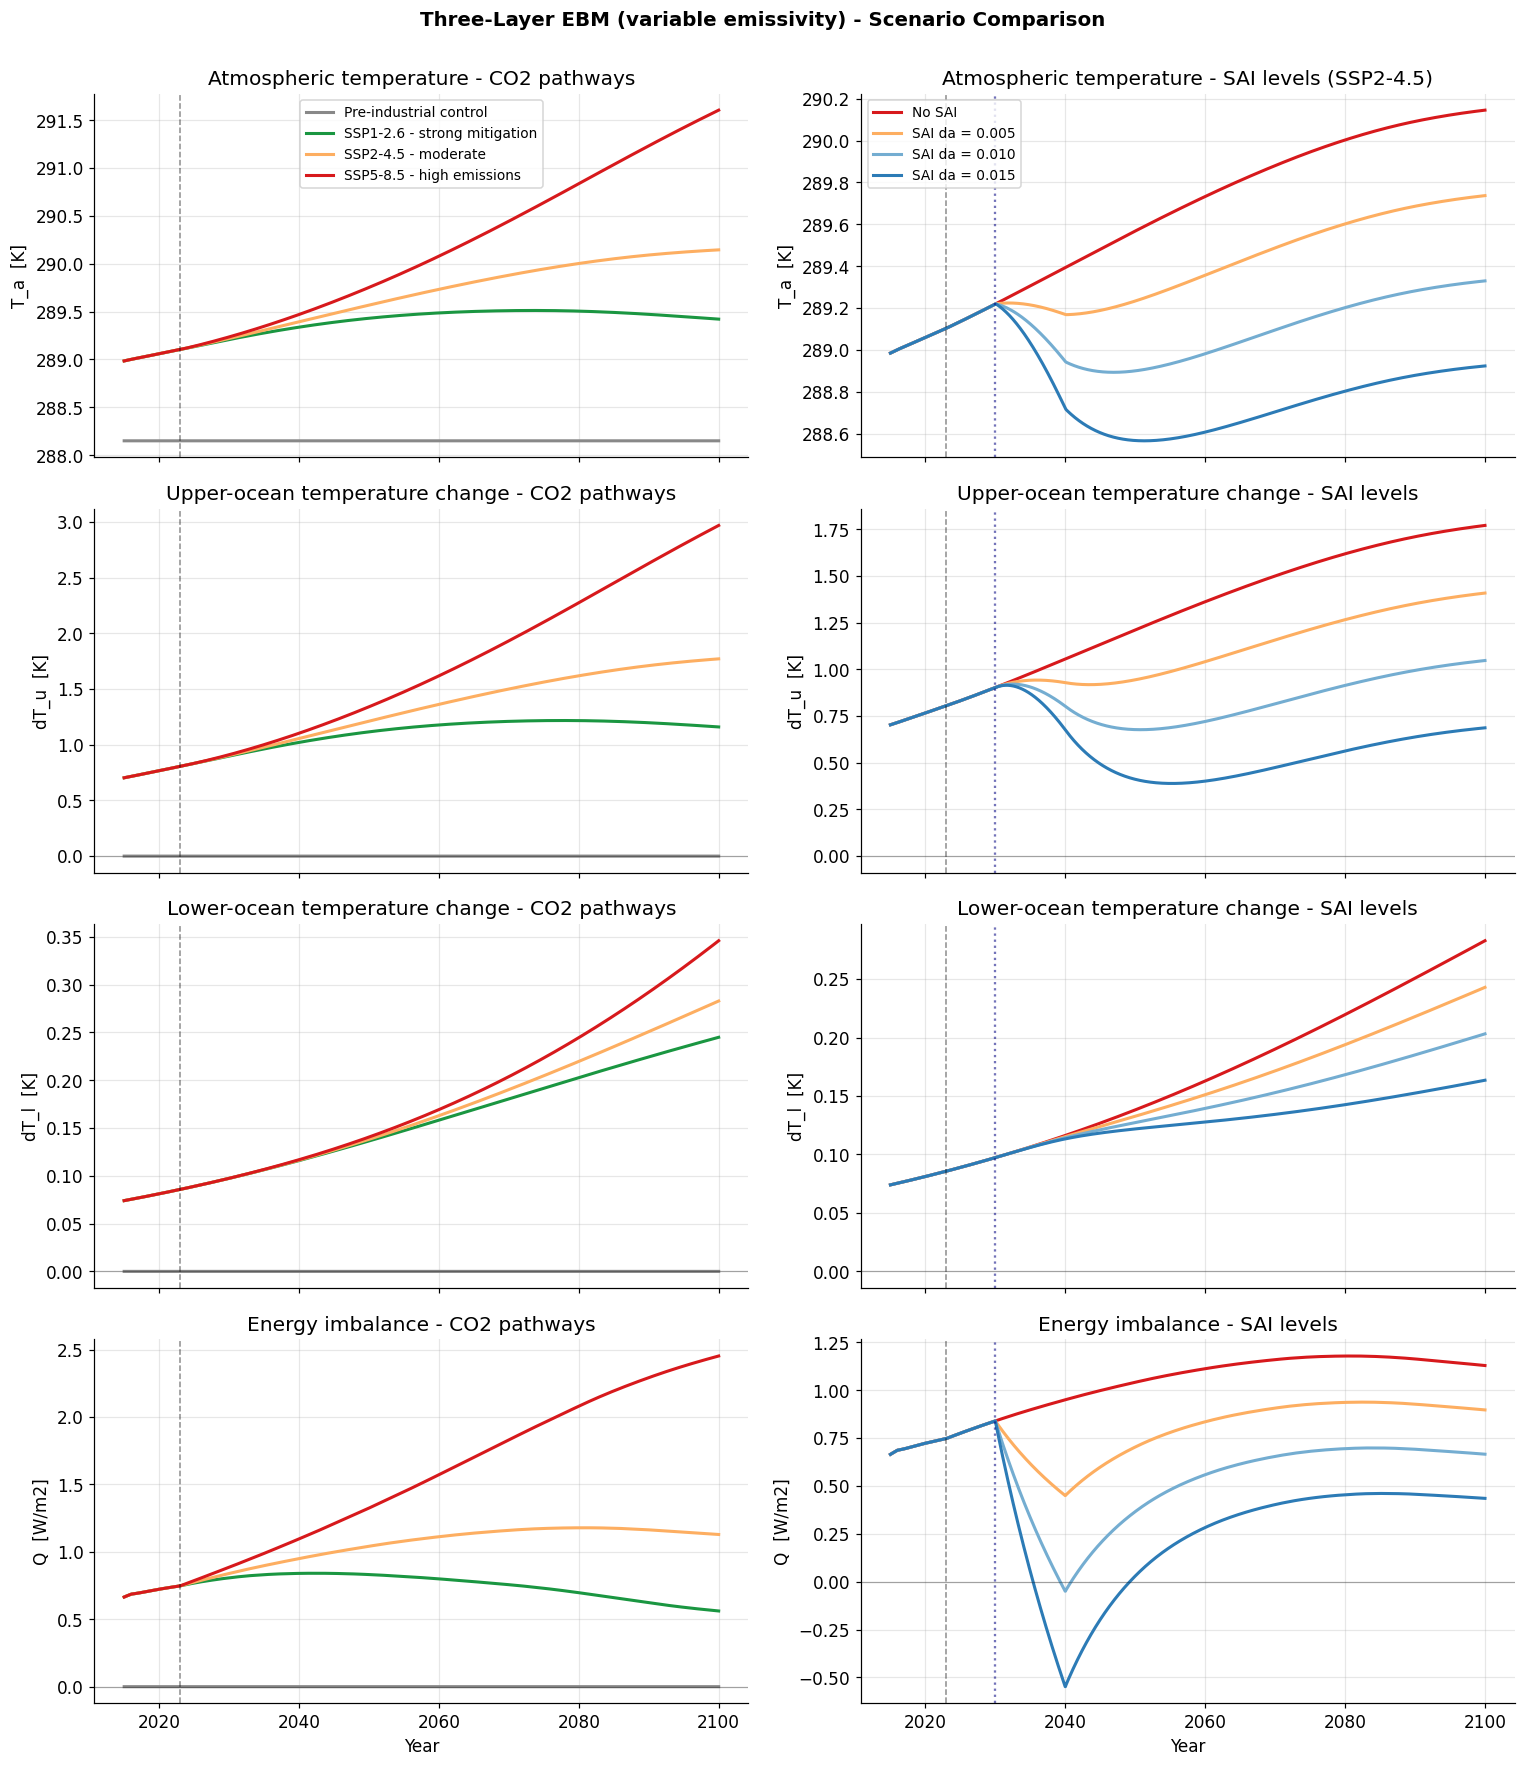

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
fig.suptitle('Three-Layer EBM (variable emissivity) - Scenario Comparison', fontsize=13, fontweight='bold', y=1.002)

# -- CO2 scenarios (no SAI), left column --------------------------------------
co2_cases = [
    ('none',   'Pre-industrial control',  '#888888'),
    ('ssp126', 'SSP1-2.6 - strong mitigation', '#1a9641'),
    ('ssp245', 'SSP2-4.5 - moderate',          '#fdae61'),
    ('ssp585', 'SSP5-8.5 - high emissions',    '#d7191c'),
]
for scen, label, color in co2_cases:
    t, Ta, Tu, Tl, Q = run_ebm(scenario=scen, d_alpha=0.0)
    axes[0, 0].plot(t, Ta,      color=color, lw=2, label=label)
    axes[1, 0].plot(t, Tu - T0, color=color, lw=2, label=label)
    axes[2, 0].plot(t, Tl - T0, color=color, lw=2, label=label)
    axes[3, 0].plot(t, Q,       color=color, lw=2, label=label)

# -- SAI levels under SSP2-4.5, right column -----------------------------------
sai_cases = [
    (0.000, 'No SAI',          '#d7191c'),
    (0.005, 'SAI da = 0.005',  '#fdae61'),
    (0.010, 'SAI da = 0.010',  '#74add1'),
    (0.015, 'SAI da = 0.015',  '#2c7bb6'),
]
for da, label, color in sai_cases:
    t, Ta, Tu, Tl, Q = run_ebm(scenario='ssp245', d_alpha=da)
    axes[0, 1].plot(t, Ta,      color=color, lw=2, label=label)
    axes[1, 1].plot(t, Tu - T0, color=color, lw=2, label=label)
    axes[2, 1].plot(t, Tl - T0, color=color, lw=2, label=label)
    axes[3, 1].plot(t, Q,       color=color, lw=2, label=label)

# -- Annotations --------------------------------------------------------------
for ax in axes.flat:
    ax.axvline(2023, color='k', ls='--', lw=1, alpha=0.45)
for ax in axes[:, 1]:
    ax.axvline(2030, color='navy', ls=':', lw=1.5, alpha=0.55)
for ax in list(axes[1, :]) + list(axes[2, :]) + list(axes[3, :]):
    ax.axhline(0, color='k', lw=0.8, alpha=0.3)

axes[0, 0].set(title='Atmospheric temperature - CO2 pathways',         ylabel='T_a  [K]')
axes[0, 1].set(title='Atmospheric temperature - SAI levels (SSP2-4.5)', ylabel='T_a  [K]')
axes[1, 0].set(title='Upper-ocean temperature change - CO2 pathways',   ylabel='dT_u  [K]')
axes[1, 1].set(title='Upper-ocean temperature change - SAI levels',     ylabel='dT_u  [K]')
axes[2, 0].set(title='Lower-ocean temperature change - CO2 pathways',   ylabel='dT_l  [K]')
axes[2, 1].set(title='Lower-ocean temperature change - SAI levels',     ylabel='dT_l  [K]')
axes[3, 0].set(title='Energy imbalance - CO2 pathways',                ylabel='Q  [W/m2]', xlabel='Year')
axes[3, 1].set(title='Energy imbalance - SAI levels',                  ylabel='Q  [W/m2]', xlabel='Year')

axes[0, 0].legend(fontsize=9)
axes[0, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## Interactive Exploration

Adjust the ocean-layer heat capacities, the atmosphere-ocean and deep-ocean coupling
($\gamma_{au}$, $\gamma_{ul}$), the CO2 pathway, and the SAI deployment to see how each
shapes the response in real time.

- **Top-left** - atmospheric temperature, with the SAI cooling offset shaded.
- **Top-right** - ocean temperature change for the **upper** (solid) and **lower**
  (dashed) layers.
- **Middle-left** - net TOA energy imbalance $Q$ and the **deep-ocean heat uptake**
  $\gamma_{ul}(T_u-T_l)$.
- **Middle-right** - the **CO2 concentration** $\mathrm{CO_2}(t)$ implied by the
  scenario and the resulting **atmospheric emissivity** $\varepsilon(\mathrm{CO_2})$.
- **Bottom-left** - energy-balance decomposition $Q = F_{\mathrm{CO_2}} +
  F_{\mathrm{SAI}} +$ OLR feedback, where the OLR feedback term is the nonlinear Planck
  response $\varepsilon(\mathrm{CO_2})\sigma(T_0^4 - T_a^4)$.
- **Bottom-right** - incoming shortwave $S(1-\alpha(t))$ vs. OLR
  $\varepsilon(\mathrm{CO_2})\sigma T_a^4$ for the SAI run, each point colored by year
  (viridis). Points above the dashed $Q=0$ line indicate a net energy gain.


In [ ]:
def plot_ebm(C_u, C_l, gamma_au, gamma_ul, scenario, d_alpha, sai_start, sai_ramp, d_alpha_slope):
    t_b, Ta_b, Tu_b, Tl_b, Q_b = run_ebm(C_u=C_u, C_l=C_l, gamma_au=gamma_au, gamma_ul=gamma_ul,
                                          scenario=scenario, d_alpha=0.0)
    t_s, Ta_s, Tu_s, Tl_s, Q_s = run_ebm(C_u=C_u, C_l=C_l, gamma_au=gamma_au, gamma_ul=gamma_ul,
                                          scenario=scenario, d_alpha=d_alpha,
                                          sai_start=sai_start, sai_ramp=sai_ramp,
                                          d_alpha_slope=d_alpha_slope)

    fig, axes = plt.subplots(3, 2, figsize=(15, 15), gridspec_kw={'height_ratios': [1, 1, 1.15]})
    fig.subplots_adjust(hspace=0.45, wspace=0.3)

    fig.suptitle(f'Three-Layer EBM (variable emissivity)  |  {scenario.upper()}  |  '
                 f'C_u={C_u:.0f}, C_l={C_l:.0f} W.yr/m2/K, gamma_au={gamma_au:.2f}, gamma_ul={gamma_ul:.2f}',
                 fontsize=12, fontweight='bold')

    # -- Atmospheric temperature -----------------------------------------------
    ax = axes[0, 0]
    ax.plot(t_b, Ta_b, color='#d7191c', lw=2, label='No SAI')
    ax.plot(t_s, Ta_s, color='#2c7bb6', lw=2,
            label=f'SAI da={d_alpha:.3f}, slope={d_alpha_slope:.4f}/yr')
    ax.fill_between(t_s, Ta_b, Ta_s, where=(Ta_s < Ta_b),
                    alpha=0.15, color='#2c7bb6', label='Cooling offset')
    ax.set(title='Atmospheric temperature', ylabel='T_a  [K]', xlabel='Year')

    # -- Ocean temperature change (upper solid, lower dashed) ------------------
    ax = axes[0, 1]
    ax.plot(t_b, Tu_b - T0, color='#d7191c', lw=2,          label='Upper, no SAI')
    ax.plot(t_s, Tu_s - T0, color='#2c7bb6', lw=2,          label='Upper, SAI')
    ax.plot(t_b, Tl_b - T0, color='#d7191c', lw=2, ls='--', label='Lower, no SAI')
    ax.plot(t_s, Tl_s - T0, color='#2c7bb6', lw=2, ls='--', label='Lower, SAI')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Ocean temperature change', ylabel='dT  [K]', xlabel='Year')

    # -- Energy imbalance + deep-ocean heat uptake ------------------------------
    ax = axes[1, 0]
    ax.plot(t_b, Q_b, color='#d7191c', lw=2, label='Q (TOA), no SAI')
    ax.plot(t_s, Q_s, color='#2c7bb6', lw=2, label='Q (TOA), SAI')
    ax.plot(t_b, gamma_ul * (Tu_b - Tl_b), color="#fe9408", lw=1.3, ls=':', label='Deep uptake, no SAI')
    ax.plot(t_s, gamma_ul * (Tu_s - Tl_s), color="#00fad5", lw=1.3, ls=':', label='Deep uptake, SAI')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Energy imbalance & deep-ocean heat uptake', ylabel='W/m2', xlabel='Year')

    # -- CO2 concentration & atmospheric emissivity -----------------------------
    ax = axes[1, 1]
    CO2_s = np.array([co2_ppm(ti, scenario=scenario) for ti in t_s])
    eps_s = emissivity(CO2_s)
    ln1 = ax.plot(t_s, CO2_s, color='#8c510a', lw=2, label='CO2  [ppm]')
    ax.set(title='CO2 concentration & atmospheric emissivity', ylabel='CO2  [ppm]', xlabel='Year')
    ax2 = ax.twinx()
    ln2 = ax2.plot(t_s, eps_s, color='#01665e', lw=2, ls='--', label='eps(CO2)')
    ax2.set_ylabel('emissivity  eps  [-]')
    ax2.grid(False)
    lns = ln1 + ln2
    ax.legend(lns, [l.get_label() for l in lns], fontsize=8, loc='upper left')

    # -- Energy-balance decomposition (SAI run) ---------------------------------
    # Exact identity:  Q = F_co2 + F_sai + F_alb + OLR_fb.
    #   OLR_fb  eps(CO2)*sigma*(T0^4 - Ta^4)          -- nonlinear Planck term
    #   F_alb   -S*(alpha_earth(Ta) - alpha_earth(T0)) -- ice-albedo feedback,
    #           POSITIVE under warming (the albedo drops as Ta rises)
    #   F_sai   -S*(alpha_net(Ta, a_SAI) - alpha_earth(Ta)) -- what the aerosol
    #           layer removes on top of the earth albedo at the CURRENT Ta.
    #           Smaller in magnitude than S*a_SAI because of the multiple
    #           reflections between the surface and the layer.
    ax = axes[2, 0]
    a_sai_t = np.array([sai_delta_alpha(ti, d_alpha=d_alpha, start_year=sai_start,
                                        ramp_years=sai_ramp, d_alpha_slope=d_alpha_slope)
                        for ti in t_s])
    F_co2  = np.array([co2_forcing(ti, scenario=scenario) for ti in t_s])
    F_sai  = -S * (alpha_net(Ta_s, a_sai_t) - alpha_earth(Ta_s))
    F_alb  = -S * (alpha_earth(Ta_s) - alpha_earth(T0))
    OLR_fb = eps_s * SIGMA * (T0**4 - Ta_s**4)
    Q_dec  = F_co2 + F_sai + F_alb + OLR_fb
    ax.fill_between(t_s, F_co2,  alpha=0.35, color='#d7191c', label='CO2 forcing  F(t)')
    ax.fill_between(t_s, F_sai,  alpha=0.35, color='#2c7bb6', label='SAI  -S*(a_net - a_earth)')
    ax.fill_between(t_s, F_alb,  alpha=0.35, color='#4daf4a', label='Ice-albedo fb  -S*(a_earth(Ta) - a_earth(T0))')
    ax.fill_between(t_s, OLR_fb, alpha=0.35, color='#fdae61', label='OLR feedback  eps*sigma*(T0^4-Ta^4)')
    ax.plot(t_s, Q_dec, 'k-', lw=1.6, label='Q  (sum)')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Energy balance decomposition (SAI run)', ylabel='W/m2', xlabel='Year')

    for ax in axes.flat[:-1]:
        ax.axvline(2023, color='k', ls='--', lw=1, alpha=0.4)
        if d_alpha > 0:
            ax.axvline(sai_start,            color='navy',      ls=':', lw=1.5, alpha=0.5)
            ax.axvline(sai_start + sai_ramp, color='steelblue', ls=':', lw=1.0, alpha=0.5)
    for ax in [axes[0, 0], axes[0, 1], axes[1, 0], axes[2, 0]]:
        ax.legend(fontsize=8)

    # -- Incoming shortwave vs. OLR, colored by year (SAI run) -----------------
    ax5 = axes[2, 1]
    alpha_s = alpha_net(Ta_s, a_sai_t)   # a_sai_t built in the decomposition block above
    S_in  = S * (1 - alpha_s)
    OLR_s = eps_s * SIGMA * Ta_s**4

    lims = [min(OLR_s.min(), S_in.min()), max(OLR_s.max(), S_in.max())]
    ax5.plot(lims, lims, color='k', lw=0.8, ls='--', alpha=0.4, label='S(1-a) = OLR  (Q = 0)')
    sc = ax5.scatter(OLR_s, S_in, c=t_s, cmap='viridis', s=14, edgecolor='none')
    fig.colorbar(sc, ax=ax5, label='Year', pad=0.01)
    ax5.set(title='Incoming shortwave vs. OLR (SAI run)',
            xlabel='OLR = eps(CO2)*sigma*T_a^4  [W/m2]', ylabel='S(1 - alpha(t))  [W/m2]')
    ax5.legend(fontsize=8, loc='upper left')

    plt.tight_layout()
    plt.show()


interact(
    plot_ebm,
    C_u          = FloatSlider(value=C_UPPER,  min=5.0,   max=40.0,  step=1.0,    description='C_u [W.yr/m2/K]',        style={'description_width': 'initial'}),
    C_l          = FloatSlider(value=C_LOWER,  min=50.0,  max=600.0, step=10.0,   description='C_l [W.yr/m2/K]',        style={'description_width': 'initial'}),
    gamma_au     = FloatSlider(value=GAMMA_AU, min=0.5,   max=20.0,  step=0.5,    description='gamma_au [W/m2/K]',      style={'description_width': 'initial'}, readout_format='.2f'),
    gamma_ul     = FloatSlider(value=GAMMA_UL, min=0.1,   max=2.0,   step=0.1,    description='gamma_ul [W/m2/K]',      style={'description_width': 'initial'}, readout_format='.2f'),
    scenario     = Dropdown(options=['none', 'ssp126', 'ssp245', 'ssp585'], value='ssp245', description='CO2 scenario'),
    d_alpha      = FloatSlider(value=0.0,  min=0.0,  max=0.015,  step=0.0005,  description='SAI da',                 style={'description_width': 'initial'}, readout_format='.4f'),
    sai_start    = IntSlider(  value=2030, min=2025, max=2080,    step=5,      description='SAI start year',         style={'description_width': 'initial'}),
    sai_ramp     = IntSlider(  value=10,   min=1,    max=30,      step=1,      description='Ramp-up years',          style={'description_width': 'initial'}),
    d_alpha_slope= FloatSlider(value=0.0,  min=0.0,  max=0.00025,  step=0.000005, description='Post-ramp slope (da/yr)', style={'description_width': 'initial'}, readout_format='.5f'),
);


interactive(children=(FloatSlider(value=18.403032607662325, description='C_u [W.yr/m2/K]', max=40.0, min=5.0, …

In [ ]:
### Controller for constant atmospheric temperature
#
# ARISE-1.5-style closed-loop SAI feedback controller (simplified analog --
# not the actual ensemble PI-controller used in ARISE, but the same two-phase
# structure):
#
#   t < 2035          : no SAI, baseline warming under the CO2 scenario
#   2035 <= t < 2045  : ramp-in -- T_target is frozen at whatever T_a is when
#                       the ramp begins (2035), and each year the controller
#                       solves for the d_alpha that would hold Ta AT T_target
#                       given the current upper-ocean state, then applies only
#                       a linearly increasing fraction of it (0 -> 1 over the
#                       decade)
#   t >= 2045         : full control -- each year the controller re-solves
#                       for the d_alpha that holds Ta at the same fixed
#                       T_target and applies it in full
#
# The "solve" is closed-form, exactly as in the two-layer model: because the
# atmospheric heat capacity C_a is tiny (~0.03 yr response time) compared to
# the annual control step, Ta relaxes to its instantaneous radiative
# equilibrium well within each year -- so choosing d_alpha to make T_target
# itself that equilibrium (given the current upper-ocean temperature T_u,
# which is what the atmosphere actually exchanges heat with) is what pins Ta.
# The deep ocean T_l has no direct radiative role and enters this solve only
# through T_u's slower drift. Setting Ta = T_target in
#   C_a dTa/dt = S(1 - alpha_net(Ta, d_alpha)) - eps(CO2(t))*sigma*Ta^4 - gamma_au*(Ta-Tu)
# and setting dTa/dt = 0 gives the ABSORBED shortwave the controller needs,
#   R_target = eps(CO2(t))*sigma*T_target^4 + gamma_au*(T_target - Tu).
# With a temperature-dependent earth albedo the required d_alpha is no longer a
# simple offset, so R_target is inverted through the multiple-reflection
# relation (alpha_sai_for_absorbed_sw, defined with the constants above):
#   d_alpha = [(1-a_e) - A] / [(1-a_e) - A*a_e],   A = R_target/S,
#                                                  a_e = alpha_earth(T_target).
# a_e is evaluated at T_target -- the temperature the controller is pinning --
# so the ice-albedo feedback is folded into the solve.

CTRL_START = 2035   # year SAI ramp-in begins
CTRL_RAMP  = 10      # ramp-in duration [yr]; full control from CTRL_START+CTRL_RAMP


def controller_d_alpha_step(T_target, Tu, t_year, scenario, gamma_au):
    '''SAI albedo offset that holds Ta at the fixed T_target, given the current upper-ocean state.'''
    eps = emissivity(co2_ppm(t_year, scenario=scenario))
    R_target = eps * SIGMA * T_target**4 + gamma_au * (T_target - Tu)
    # inverse of alpha_net(), already clipped at 0 -- SAI only adds reflective
    # aerosol, so a negative solution means "no injection"
    return alpha_sai_for_absorbed_sw(T_target, R_target)


def _layer_derivs_fixed_alpha(t, y, C_a, C_u, C_l, gamma_au, gamma_ul, d_alpha, scenario):
    '''Three-layer RHS with a single, already-solved albedo offset held fixed.'''
    Ta, Tu, Tl = y
    eps  = emissivity(co2_ppm(t, scenario=scenario))
    R    = S * (1 - alpha_net(Ta, d_alpha)) - eps * SIGMA * Ta**4
    f_au = gamma_au * (Ta - Tu)
    f_ul = gamma_ul * (Tu - Tl)
    return [(R - f_au) / C_a, (f_au - f_ul) / C_u, f_ul / C_l]


def run_controller_ebm(C_u=C_UPPER, C_l=C_LOWER, gamma_au=GAMMA_AU, gamma_ul=GAMMA_UL,
                        scenario='ssp245', t_span=None, pts_per_year=8,
                        ctrl_start=CTRL_START, ctrl_ramp=CTRL_RAMP):
    '''
    Integrate the three-layer EBM one calendar year at a time, re-solving the
    controller's d_alpha at the start of each year (see module docstring
    above) and holding it fixed while that year is integrated. ctrl_start/
    ctrl_ramp default to the module-level CTRL_START/CTRL_RAMP but can be
    overridden to explore a different deployment year.

    Returns
    -------
    t, Ta, Tu, Tl, Q, d_alpha : all on the same fine (sub-year) grid.
    T_target                   : the frozen atmospheric-temperature target [K].
    '''
    C_a = C_ATMOS
    t0, t_end = _resolve_t_span(t_span)
    years = np.arange(t0, t_end)

    t_chunks, Ta_chunks, Tu_chunks, Tl_chunks, da_chunks = [], [], [], [], []
    y = list(initial_state(t0, C_a, C_u, C_l, gamma_au, gamma_ul, scenario))
    T_target = None

    for yr in years:
        if yr < ctrl_start:
            d_alpha = 0.0
        else:
            if T_target is None:
                T_target = y[0]   # freeze the target at the state when the ramp begins
            d_alpha_full = controller_d_alpha_step(T_target, y[1], yr, scenario, gamma_au)
            ramp_frac = min(1.0, (yr - ctrl_start + 1) / ctrl_ramp)
            d_alpha = ramp_frac * d_alpha_full

        t_eval = np.linspace(yr, yr + 1, pts_per_year, endpoint=False)
        sol = solve_ivp(lambda t, yy: _layer_derivs_fixed_alpha(t, yy, C_a, C_u, C_l, gamma_au, gamma_ul,
                                                                  d_alpha, scenario),
                        (yr, yr + 1), y, t_eval=t_eval,
                        method='BDF', rtol=1e-8, atol=1e-10, dense_output=True)

        t_chunks.append(sol.t)
        Ta_chunks.append(sol.y[0])
        Tu_chunks.append(sol.y[1])
        Tl_chunks.append(sol.y[2])
        da_chunks.append(np.full_like(sol.t, d_alpha))
        y = sol.sol(yr + 1)   # true state at the year boundary (t_eval excludes it via
                               # endpoint=False, so sol.y[:, -1] is the state at
                               # yr+0.875 -- using that as next year's IC silently skips
                               # the last 1/pts_per_year of each year)

    t  = np.concatenate(t_chunks)
    Ta = np.concatenate(Ta_chunks)
    Tu = np.concatenate(Tu_chunks)
    Tl = np.concatenate(Tl_chunks)
    d_alpha_t = np.concatenate(da_chunks)

    eps_t = emissivity(np.array([co2_ppm(ti, scenario=scenario) for ti in t]))
    Q = S * (1 - alpha_net(Ta, d_alpha_t)) - eps_t * SIGMA * Ta**4
    return t, Ta, Tu, Tl, Q, d_alpha_t, T_target


def plot_controller_ebm(C_u, C_l, gamma_au, gamma_ul, scenario):
    t_c, Ta_c, Tu_c, Tl_c, Q_c, da_c, T_target = run_controller_ebm(
        C_u=C_u, C_l=C_l, gamma_au=gamma_au, gamma_ul=gamma_ul, scenario=scenario)
    t_b, Ta_b, Tu_b, Tl_b, Q_b = run_ebm(
        C_u=C_u, C_l=C_l, gamma_au=gamma_au, gamma_ul=gamma_ul, scenario=scenario, d_alpha=0.0)

    fig, axes = plt.subplots(3, 2, figsize=(15, 15), gridspec_kw={'height_ratios': [1, 1, 1.15]})
    fig.subplots_adjust(hspace=0.45, wspace=0.3)

    fig.suptitle(f'Three-Layer EBM  |  Constant-T_a SAI Controller  |  {scenario.upper()}  |  '
                 f'C_u={C_u:.0f}, C_l={C_l:.0f} W.yr/m2/K, gamma_au={gamma_au:.2f}, gamma_ul={gamma_ul:.2f}',
                 fontsize=12, fontweight='bold')

    # -- Atmospheric temperature -----------------------------------------------
    ax = axes[0, 0]
    ax.plot(t_b, Ta_b, color='#d7191c', lw=2, label='No SAI (baseline)')
    ax.plot(t_c, Ta_c, color='#2c7bb6', lw=2, label='Controller (constant T_a)')
    if T_target is not None:
        ax.axhline(T_target, color='#2c7bb6', lw=1, ls=':', alpha=0.6, label=f'T_target = {T_target:.2f} K')
    ax.set(title='Atmospheric temperature', ylabel='T_a  [K]', xlabel='Year')

    # -- Ocean temperature change (upper solid, lower dashed) -------------------
    ax = axes[0, 1]
    ax.plot(t_b, Tu_b - T0, color='#d7191c', lw=2,          label='Upper, no SAI')
    ax.plot(t_c, Tu_c - T0, color='#2c7bb6', lw=2,          label='Upper, controller')
    ax.plot(t_b, Tl_b - T0, color='#d7191c', lw=2, ls='--', label='Lower, no SAI')
    ax.plot(t_c, Tl_c - T0, color='#2c7bb6', lw=2, ls='--', label='Lower, controller')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Ocean temperature change', ylabel='dT  [K]', xlabel='Year')

    # -- Energy imbalance + deep-ocean heat uptake ------------------------------
    ax = axes[1, 0]
    ax.plot(t_b, Q_b, color='#d7191c', lw=2, label='Q (TOA), no SAI')
    ax.plot(t_c, Q_c, color='#2c7bb6', lw=2, label='Q (TOA), controller')
    ax.plot(t_b, gamma_ul * (Tu_b - Tl_b), color="#fe9408", lw=1.3, ls=':', label='Deep uptake, no SAI')
    ax.plot(t_c, gamma_ul * (Tu_c - Tl_c), color="#00fad5", lw=1.3, ls=':', label='Deep uptake, controller')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Energy imbalance & deep-ocean heat uptake', ylabel='W/m2', xlabel='Year')

    # -- CO2 concentration & atmospheric emissivity -----------------------------
    ax = axes[1, 1]
    CO2_c = np.array([co2_ppm(ti, scenario=scenario) for ti in t_c])
    eps_c = emissivity(CO2_c)
    ln1 = ax.plot(t_c, CO2_c, color='#8c510a', lw=2, label='CO2  [ppm]')
    ax.set(title='CO2 concentration & atmospheric emissivity', ylabel='CO2  [ppm]', xlabel='Year')
    ax2 = ax.twinx()
    ln2 = ax2.plot(t_c, eps_c, color='#01665e', lw=2, ls='--', label='eps(CO2)')
    ax2.set_ylabel('emissivity  eps  [-]')
    ax2.grid(False)
    lns = ln1 + ln2
    ax.legend(lns, [l.get_label() for l in lns], fontsize=8, loc='upper left')

    # -- Controller SAI injection ------------------------------------------------
    ax = axes[2, 0]
    ax.plot(t_c, da_c, color='#762a83', lw=2, label='SAI d_alpha (solved)')
    ax.set(title='Controller SAI injection', ylabel='d_alpha  [-]', xlabel='Year')
    ax.legend(fontsize=8)

    for ax in axes.flat[:-1]:
        ax.axvline(2023, color='k', ls='--', lw=1, alpha=0.4)
        ax.axvline(CTRL_START,            color='navy',      ls=':', lw=1.5, alpha=0.5)
        ax.axvline(CTRL_START + CTRL_RAMP, color='steelblue', ls=':', lw=1.0, alpha=0.5)
    for ax in [axes[0, 0], axes[0, 1], axes[1, 0]]:
        ax.legend(fontsize=8)

    # -- Incoming shortwave vs. OLR, colored by year (controller run) ----------
    ax5 = axes[2, 1]
    S_in  = S * (1 - alpha_net(Ta_c, da_c))
    OLR_c = eps_c * SIGMA * Ta_c**4

    year_labels, year_idx = np.unique(np.floor(t_c).astype(int), return_inverse=True)
    counts       = np.bincount(year_idx)
    S_in_annual  = np.bincount(year_idx, weights=S_in)  / counts
    OLR_annual   = np.bincount(year_idx, weights=OLR_c) / counts

    lims = [min(OLR_annual.min(), S_in_annual.min()), max(OLR_annual.max(), S_in_annual.max())]
    ax5.plot(lims, lims, color='k', lw=0.8, ls='--', alpha=0.4, label='S(1-a) = OLR  (Q = 0)')
    sc = ax5.scatter(OLR_annual, S_in_annual, c=year_labels, cmap='viridis', s=14, edgecolor='none')
    fig.colorbar(sc, ax=ax5, label='Year', pad=0.01)
    ax5.set(title='Incoming shortwave vs. OLR (controller run, annual means)',
            xlabel='OLR = eps(CO2)*sigma*T_a^4  [W/m2]', ylabel='S(1 - alpha(t))  [W/m2]')
    ax5.legend(fontsize=8, loc='upper left')

    plt.tight_layout()
    plt.show()


interact(
    plot_controller_ebm,
    C_u      = FloatSlider(value=C_UPPER,  min=5.0,  max=40.0,  step=1.0,  description='C_u [W.yr/m2/K]',   style={'description_width': 'initial'}),
    C_l      = FloatSlider(value=C_LOWER,  min=50.0, max=600.0, step=10.0, description='C_l [W.yr/m2/K]',   style={'description_width': 'initial'}),
    gamma_au = FloatSlider(value=GAMMA_AU, min=0.5,  max=20.0,  step=0.5,  description='gamma_au [W/m2/K]', style={'description_width': 'initial'}, readout_format='.2f'),
    gamma_ul = FloatSlider(value=GAMMA_UL, min=0.1,  max=2.0,   step=0.1,  description='gamma_ul [W/m2/K]', style={'description_width': 'initial'}, readout_format='.2f'),
    scenario = Dropdown(options=['none', 'ssp126', 'ssp245', 'ssp585'], value='ssp245', description='CO2 scenario'),
);


interactive(children=(FloatSlider(value=18.403032607662325, description='C_u [W.yr/m2/K]', max=40.0, min=5.0, …

In [ ]:
### Controller for zero TOA imbalance (incoming shortwave = OLR)
#
# Same closed-loop, two-phase (ramp-in then full control) structure as the
# constant-T_a controller above, but with a different control target: instead
# of pinning Ta at a fixed value, each year the controller solves for the
# d_alpha that makes incoming shortwave equal outgoing longwave -- i.e. zeros
# the net TOA imbalance Q -- given the atmospheric temperature at the start of
# that year.
#
#   t < 2035          : no SAI, baseline warming under the CO2 scenario
#   2035 <= t < 2045  : ramp-in -- each year the controller solves for the
#                       d_alpha that would make Q = 0 given the current Ta,
#                       then applies only a linearly increasing fraction of
#                       it (0 -> 1 over the decade)
#   t >= 2045         : full control -- each year the controller re-solves
#                       for the d_alpha that zeros Q and applies it in full
#
# Unlike the constant-T_a controller, this target is purely radiative: Q
# doesn't depend on either ocean layer, so the solve doesn't need Tu or Tl.
# Setting Q = 0 in
#   Q = S(1 - alpha_net(Ta, d_alpha)) - eps(CO2(t))*sigma*Ta^4
# solving for d_alpha means requiring the absorbed shortwave to equal the OLR,
#   R_target = eps(CO2(t))*sigma*Ta^4,
# then inverting the multiple-reflection relation for the SAI-layer albedo:
#   d_alpha = [(1-a_e) - A] / [(1-a_e) - A*a_e],   A = R_target/S,
#                                                  a_e = alpha_earth(Ta).
# Because this is solved from the current (not a frozen-target) Ta, Ta is
# still free to drift year to year -- the controller only holds the annual
# imbalance at zero, not the temperature itself.

def controller_d_alpha_step_qbal(Ta, t_year, scenario):
    '''SAI albedo offset that makes S(1-alpha) = OLR (zero TOA imbalance) at the given Ta.'''
    eps = emissivity(co2_ppm(t_year, scenario=scenario))
    R_target = eps * SIGMA * Ta**4          # absorbed shortwave must equal OLR
    return alpha_sai_for_absorbed_sw(Ta, R_target)


def run_controller_ebm_qbal(C_u=C_UPPER, C_l=C_LOWER, gamma_au=GAMMA_AU, gamma_ul=GAMMA_UL,
                             scenario='ssp245', t_span=None, pts_per_year=8):
    '''
    Integrate the three-layer EBM one calendar year at a time, re-solving the
    Q=0 controller's d_alpha at the start of each year (see module docstring
    above) and holding it fixed while that year is integrated.

    Returns
    -------
    t, Ta, Tu, Tl, Q, d_alpha : all on the same fine (sub-year) grid.
    '''
    C_a = C_ATMOS
    t0, t_end = _resolve_t_span(t_span)
    years = np.arange(t0, t_end)

    t_chunks, Ta_chunks, Tu_chunks, Tl_chunks, da_chunks = [], [], [], [], []
    y = list(initial_state(t0, C_a, C_u, C_l, gamma_au, gamma_ul, scenario))

    for yr in years:
        if yr < CTRL_START:
            d_alpha = 0.0
        else:
            d_alpha_full = controller_d_alpha_step_qbal(y[0], yr, scenario)
            ramp_frac = min(1.0, (yr - CTRL_START + 1) / CTRL_RAMP)
            d_alpha = ramp_frac * d_alpha_full

        t_eval = np.linspace(yr, yr + 1, pts_per_year, endpoint=False)
        sol = solve_ivp(lambda t, yy: _layer_derivs_fixed_alpha(t, yy, C_a, C_u, C_l, gamma_au, gamma_ul,
                                                                  d_alpha, scenario),
                        (yr, yr + 1), y, t_eval=t_eval,
                        method='BDF', rtol=1e-8, atol=1e-10, dense_output=True)

        t_chunks.append(sol.t)
        Ta_chunks.append(sol.y[0])
        Tu_chunks.append(sol.y[1])
        Tl_chunks.append(sol.y[2])
        da_chunks.append(np.full_like(sol.t, d_alpha))
        y = sol.sol(yr + 1)   # true state at the year boundary -- see the same note
                               # in run_controller_ebm above

    t  = np.concatenate(t_chunks)
    Ta = np.concatenate(Ta_chunks)
    Tu = np.concatenate(Tu_chunks)
    Tl = np.concatenate(Tl_chunks)
    d_alpha_t = np.concatenate(da_chunks)

    eps_t = emissivity(np.array([co2_ppm(ti, scenario=scenario) for ti in t]))
    Q = S * (1 - alpha_net(Ta, d_alpha_t)) - eps_t * SIGMA * Ta**4
    return t, Ta, Tu, Tl, Q, d_alpha_t


def plot_controller_ebm_qbal(C_u, C_l, gamma_au, gamma_ul, scenario):
    t_c, Ta_c, Tu_c, Tl_c, Q_c, da_c = run_controller_ebm_qbal(
        C_u=C_u, C_l=C_l, gamma_au=gamma_au, gamma_ul=gamma_ul, scenario=scenario)
    t_b, Ta_b, Tu_b, Tl_b, Q_b = run_ebm(
        C_u=C_u, C_l=C_l, gamma_au=gamma_au, gamma_ul=gamma_ul, scenario=scenario, d_alpha=0.0)

    fig, axes = plt.subplots(3, 2, figsize=(15, 15), gridspec_kw={'height_ratios': [1, 1, 1.15]})
    fig.subplots_adjust(hspace=0.45, wspace=0.3)

    fig.suptitle(f'Three-Layer EBM  |  Zero-Imbalance (Q=0) SAI Controller  |  {scenario.upper()}  |  '
                 f'C_u={C_u:.0f}, C_l={C_l:.0f} W.yr/m2/K, gamma_au={gamma_au:.2f}, gamma_ul={gamma_ul:.2f}',
                 fontsize=12, fontweight='bold')

    # -- Atmospheric temperature -----------------------------------------------
    ax = axes[0, 0]
    ax.plot(t_b, Ta_b, color='#d7191c', lw=2, label='No SAI (baseline)')
    ax.plot(t_c, Ta_c, color='#2c7bb6', lw=2, label='Controller (Q = 0)')
    ax.set(title='Atmospheric temperature', ylabel='T_a  [K]', xlabel='Year')

    # -- Ocean temperature change (upper solid, lower dashed) -------------------
    ax = axes[0, 1]
    ax.plot(t_b, Tu_b - T0, color='#d7191c', lw=2,          label='Upper, no SAI')
    ax.plot(t_c, Tu_c - T0, color='#2c7bb6', lw=2,          label='Upper, controller')
    ax.plot(t_b, Tl_b - T0, color='#d7191c', lw=2, ls='--', label='Lower, no SAI')
    ax.plot(t_c, Tl_c - T0, color='#2c7bb6', lw=2, ls='--', label='Lower, controller')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Ocean temperature change', ylabel='dT  [K]', xlabel='Year')

    # -- Energy imbalance + deep-ocean heat uptake ------------------------------
    ax = axes[1, 0]
    ax.plot(t_b, Q_b, color='#d7191c', lw=2, label='Q (TOA), no SAI')
    ax.plot(t_c, Q_c, color='#2c7bb6', lw=2, label='Q (TOA), controller')
    ax.plot(t_b, gamma_ul * (Tu_b - Tl_b), color="#fe9408", lw=1.3, ls=':', label='Deep uptake, no SAI')
    ax.plot(t_c, gamma_ul * (Tu_c - Tl_c), color="#00fad5", lw=1.3, ls=':', label='Deep uptake, controller')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set(title='Energy imbalance & deep-ocean heat uptake', ylabel='W/m2', xlabel='Year')

    # -- CO2 concentration & atmospheric emissivity -----------------------------
    ax = axes[1, 1]
    CO2_c = np.array([co2_ppm(ti, scenario=scenario) for ti in t_c])
    eps_c = emissivity(CO2_c)
    ln1 = ax.plot(t_c, CO2_c, color='#8c510a', lw=2, label='CO2  [ppm]')
    ax.set(title='CO2 concentration & atmospheric emissivity', ylabel='CO2  [ppm]', xlabel='Year')
    ax2 = ax.twinx()
    ln2 = ax2.plot(t_c, eps_c, color='#01665e', lw=2, ls='--', label='eps(CO2)')
    ax2.set_ylabel('emissivity  eps  [-]')
    ax2.grid(False)
    lns = ln1 + ln2
    ax.legend(lns, [l.get_label() for l in lns], fontsize=8, loc='upper left')

    # -- Controller SAI injection ------------------------------------------------
    ax = axes[2, 0]
    ax.plot(t_c, da_c, color='#762a83', lw=2, label='SAI d_alpha (solved)')
    ax.set(title='Controller SAI injection', ylabel='d_alpha  [-]', xlabel='Year')
    ax.legend(fontsize=8)

    for ax in axes.flat[:-1]:
        ax.axvline(2023, color='k', ls='--', lw=1, alpha=0.4)
        ax.axvline(CTRL_START,            color='navy',      ls=':', lw=1.5, alpha=0.5)
        ax.axvline(CTRL_START + CTRL_RAMP, color='steelblue', ls=':', lw=1.0, alpha=0.5)
    for ax in [axes[0, 0], axes[0, 1], axes[1, 0]]:
        ax.legend(fontsize=8)

    # -- Incoming shortwave vs. OLR, colored by year (controller run) ----------
    ax5 = axes[2, 1]
    S_in  = S * (1 - alpha_net(Ta_c, da_c))
    OLR_c = eps_c * SIGMA * Ta_c**4

    year_labels, year_idx = np.unique(np.floor(t_c).astype(int), return_inverse=True)
    counts       = np.bincount(year_idx)
    S_in_annual  = np.bincount(year_idx, weights=S_in)  / counts
    OLR_annual   = np.bincount(year_idx, weights=OLR_c) / counts

    lims = [min(OLR_annual.min(), S_in_annual.min()), max(OLR_annual.max(), S_in_annual.max())]
    ax5.plot(lims, lims, color='k', lw=0.8, ls='--', alpha=0.4, label='S(1-a) = OLR  (Q = 0)')
    sc = ax5.scatter(OLR_annual, S_in_annual, c=year_labels, cmap='viridis', s=14, edgecolor='none')
    fig.colorbar(sc, ax=ax5, label='Year', pad=0.01)
    ax5.set(title='Incoming shortwave vs. OLR (controller run, annual means)',
            xlabel='OLR = eps(CO2)*sigma*T_a^4  [W/m2]', ylabel='S(1 - alpha(t))  [W/m2]')
    ax5.legend(fontsize=8, loc='upper left')

    plt.tight_layout()
    plt.show()


interact(
    plot_controller_ebm_qbal,
    C_u      = FloatSlider(value=C_UPPER,  min=5.0,  max=40.0,  step=1.0,  description='C_u [W.yr/m2/K]',   style={'description_width': 'initial'}),
    C_l      = FloatSlider(value=C_LOWER,  min=50.0, max=600.0, step=10.0, description='C_l [W.yr/m2/K]',   style={'description_width': 'initial'}),
    gamma_au = FloatSlider(value=GAMMA_AU, min=0.5,  max=20.0,  step=0.5,  description='gamma_au [W/m2/K]', style={'description_width': 'initial'}, readout_format='.2f'),
    gamma_ul = FloatSlider(value=GAMMA_UL, min=0.1,  max=2.0,   step=0.1,  description='gamma_ul [W/m2/K]', style={'description_width': 'initial'}, readout_format='.2f'),
    scenario = Dropdown(options=['none', 'ssp126', 'ssp245', 'ssp585'], value='ssp245', description='CO2 scenario'),
);


interactive(children=(FloatSlider(value=18.403032607662325, description='C_u [W.yr/m2/K]', max=40.0, min=5.0, …

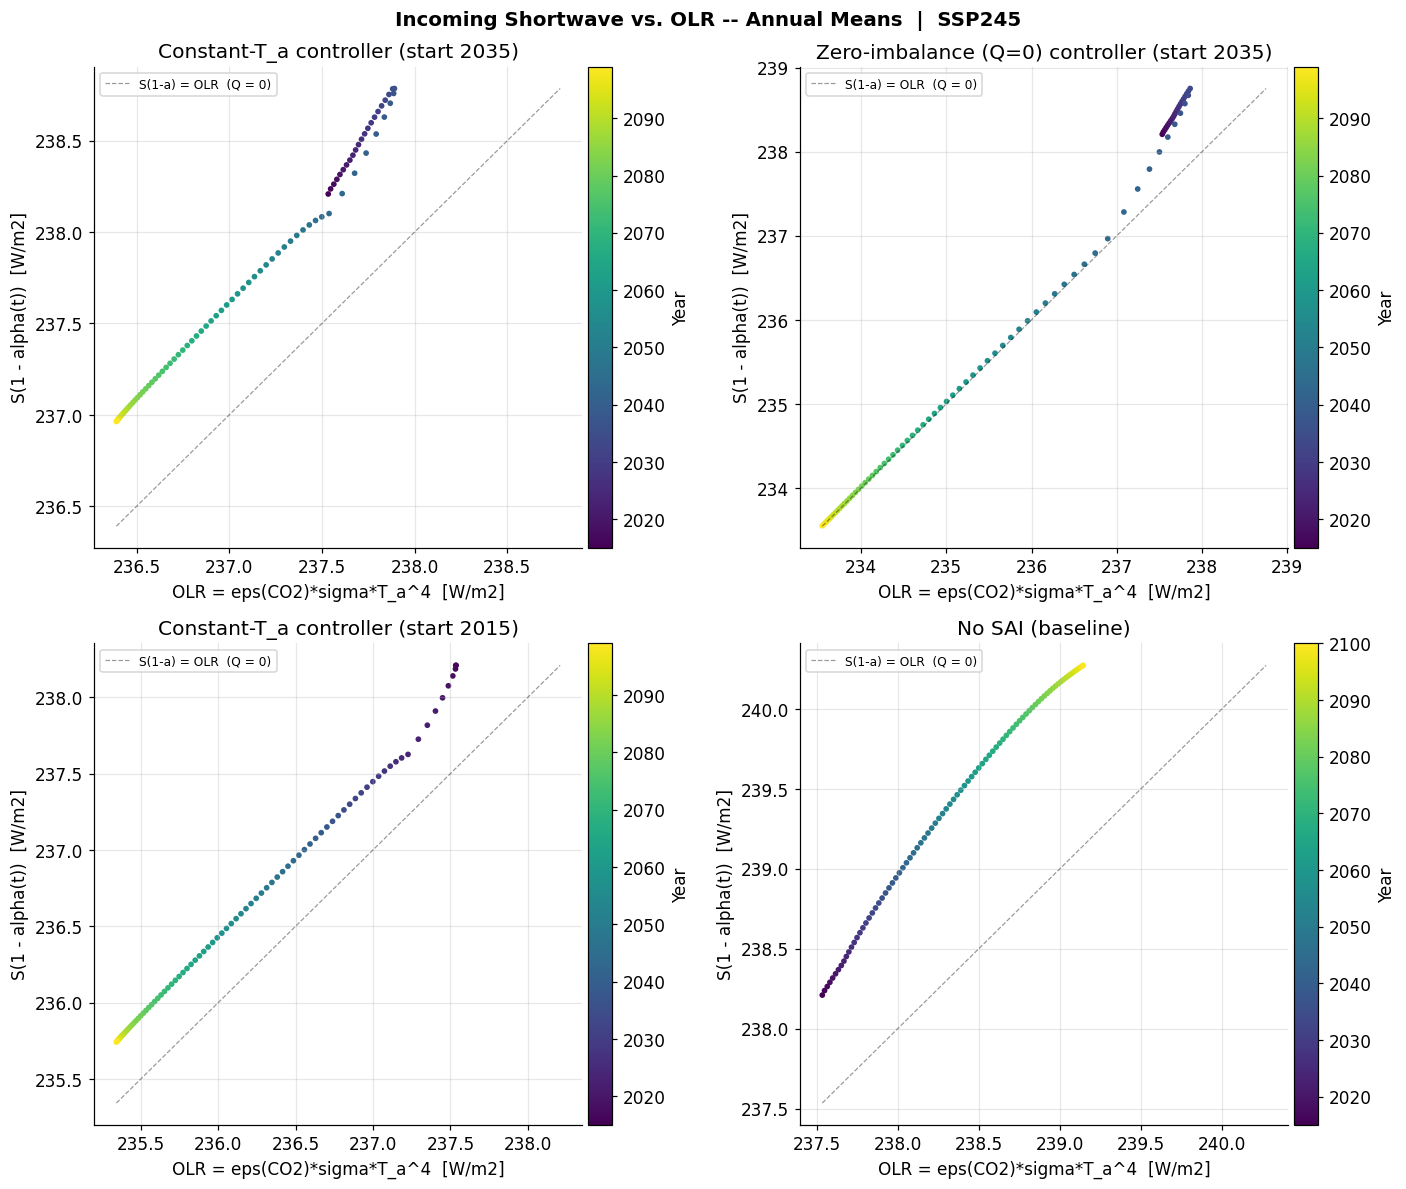

In [20]:
def _annual_mean_shortwave_olr(ax, t, Ta, d_alpha_t, scenario, title):
    '''Annual-mean incoming shortwave vs. OLR scatter, colored by year (same
    construction as the bottom-right panel of each controller plot above).'''
    eps  = emissivity(np.array([co2_ppm(ti, scenario=scenario) for ti in t]))
    S_in = S * (1 - alpha_net(Ta, d_alpha_t))
    OLR  = eps * SIGMA * Ta**4

    year_labels, year_idx = np.unique(np.floor(t).astype(int), return_inverse=True)
    counts      = np.bincount(year_idx)
    S_in_annual = np.bincount(year_idx, weights=S_in) / counts
    OLR_annual  = np.bincount(year_idx, weights=OLR)  / counts

    lims = [min(OLR_annual.min(), S_in_annual.min()), max(OLR_annual.max(), S_in_annual.max())]
    ax.plot(lims, lims, color='k', lw=0.8, ls='--', alpha=0.4, label='S(1-a) = OLR  (Q = 0)')
    sc = ax.scatter(OLR_annual, S_in_annual, c=year_labels, cmap='viridis', s=14, edgecolor='none')
    ax.set(title=title, xlabel='OLR = eps(CO2)*sigma*T_a^4  [W/m2]', ylabel='S(1 - alpha(t))  [W/m2]')
    ax.legend(fontsize=8, loc='upper left')
    return sc


_SCEN = 'ssp245'

# Constant-T_a controller, current default deployment year (module CTRL_START)
t_ctrl_2035, Ta_ctrl_2035, _, _, _, da_ctrl_2035, _ = run_controller_ebm(scenario=_SCEN)
# Zero-imbalance (Q=0) controller, current default deployment year
t_qbal, Ta_qbal, _, _, _, da_qbal = run_controller_ebm_qbal(scenario=_SCEN)
# Constant-T_a controller, deployed starting 2015 instead of 2035
t_ctrl_2015, Ta_ctrl_2015, _, _, _, da_ctrl_2015, _ = run_controller_ebm(scenario=_SCEN, ctrl_start=2015)
# No SAI at all -- plain baseline warming
t_base, Ta_base, _, _, _ = run_ebm(scenario=_SCEN, d_alpha=0.0)
da_base = np.zeros_like(t_base)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle(f'Incoming Shortwave vs. OLR -- Annual Means  |  {_SCEN.upper()}',
             fontsize=13, fontweight='bold')

panels = [
    (axes[0, 0], t_ctrl_2035, Ta_ctrl_2035, da_ctrl_2035, f'Constant-T_a controller (start {CTRL_START})'),
    (axes[0, 1], t_qbal,      Ta_qbal,      da_qbal,      'Zero-imbalance (Q=0) controller (start 2035)'),
    (axes[1, 0], t_ctrl_2015, Ta_ctrl_2015, da_ctrl_2015, 'Constant-T_a controller (start 2015)'),
    (axes[1, 1], t_base,      Ta_base,      da_base,      'No SAI (baseline)'),
]
for ax, t_p, Ta_p, da_p, title in panels:
    sc = _annual_mean_shortwave_olr(ax, t_p, Ta_p, da_p, _SCEN, title)
    fig.colorbar(sc, ax=ax, label='Year', pad=0.01)

plt.tight_layout()
plt.show()


## Deep-Ocean Coupling Sensitivity

The key new tunable parameter carried over from the multi-layer model is
$\gamma_{ul}$: a larger $\gamma_{ul}$ lets heat drain into the lower ocean faster -
warming the deep ocean but **slowing** surface warming and **raising** the persistent
energy imbalance $Q$. Below: all three layers' responses for five values of
$\gamma_{ul}$ under SSP2-4.5 with a moderate SAI deployment ($\Delta\alpha = 0.010$).


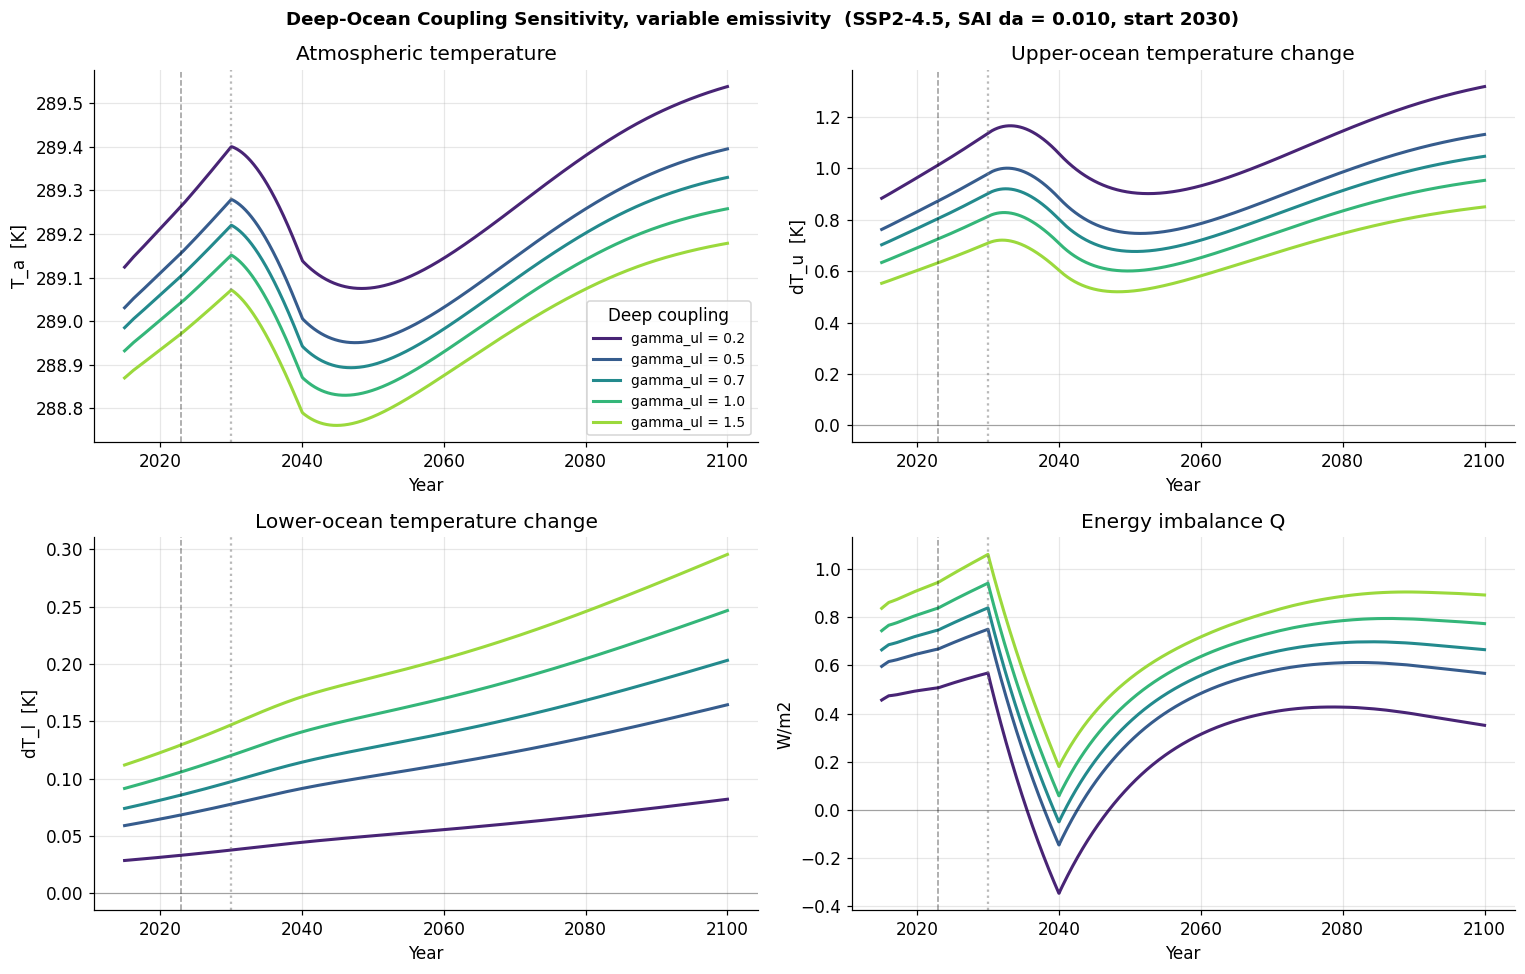

In [21]:
gamma_values = [0.2, 0.5, 0.7, 1.0, 1.5]
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(gamma_values)))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Deep-Ocean Coupling Sensitivity, variable emissivity  (SSP2-4.5, SAI da = 0.010, start 2030)',
             fontsize=12, fontweight='bold')

for g, color in zip(gamma_values, colors):
    t, Ta, Tu, Tl, Q = run_ebm(scenario='ssp245', d_alpha=0.010, gamma_ul=g)
    axes[0, 0].plot(t, Ta,      color=color, lw=2, label=f'gamma_ul = {g}')
    axes[0, 1].plot(t, Tu - T0, color=color, lw=2)
    axes[1, 0].plot(t, Tl - T0, color=color, lw=2)
    axes[1, 1].plot(t, Q,       color=color, lw=2)

for ax in axes.flat:
    ax.axvline(2023, color='k',    ls='--', lw=1,   alpha=0.4)
    ax.axvline(2030, color='gray', ls=':',  lw=1.5, alpha=0.55)
for ax in (axes[0, 1], axes[1, 0], axes[1, 1]):
    ax.axhline(0, color='k', lw=0.8, alpha=0.3)

axes[0, 0].set(title='Atmospheric temperature',          ylabel='T_a  [K]',  xlabel='Year')
axes[0, 1].set(title='Upper-ocean temperature change',   ylabel='dT_u  [K]', xlabel='Year')
axes[1, 0].set(title='Lower-ocean temperature change',   ylabel='dT_l  [K]', xlabel='Year')
axes[1, 1].set(title='Energy imbalance Q',               ylabel='W/m2',      xlabel='Year')

axes[0, 0].legend(title='Deep coupling', fontsize=9)

plt.tight_layout()
plt.show()
